In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('sales_data_with_discounts.csv')



In [3]:
df.head(5)

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [4]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
print("Numerical Columns:", numerical_cols.tolist())

Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


In [ ]:
#basic statistical measures
stats = df[numerical_cols].agg(['mean', 'median', 'std'])

# Mode is calculated separately
modes = df[numerical_cols].mode().iloc[0]
stats.loc['mode'] = modes

print(stats)

          Volume     Avg Price  Total Sales Value  Discount Rate (%)  \
mean    5.066667  10453.433333       33812.835556          15.155242   
median  4.000000   1450.000000        5700.000000          16.577766   
std     4.231602  18079.904840       50535.074173           4.220602   
mode    3.000000    400.000000       24300.000000           5.007822   

        Discount Amount  Net Sales Value  
mean        3346.499424     30466.336131  
median       988.933733      4677.788059  
std         4509.902963     46358.656624  
mode          69.177942       326.974801  


In [6]:
df.describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


In [11]:
df.select_dtypes(include='object')

C:\Users\saipr\AppData\Local\Temp\ipykernel_24824\676392701.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object')


,Date,Day,SKU,City,BU,Brand,Model
0,01-04-2021,Thursday,M01,C,Mobiles,RealU,RU-10
1,01-04-2021,Thursday,M02,C,Mobiles,RealU,RU-9 Plus
2,01-04-2021,Thursday,M03,C,Mobiles,YouM,YM-99
3,01-04-2021,Thursday,M04,C,Mobiles,YouM,YM-99 Plus
4,01-04-2021,Thursday,M05,C,Mobiles,YouM,YM-98
...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,Lifestyle,Jeera,M-Casuals
446,15-04-2021,Thursday,L07,C,Lifestyle,Viva,W-Western
447,15-04-2021,Thursday,L08,C,Lifestyle,Viva,W-Lounge
448,15-04-2021,Thursday,L09,C,Lifestyle,Jeera,M-Formals


In [12]:
df.select_dtypes(include='object').describe()

C:\Users\saipr\AppData\Local\Temp\ipykernel_24824\2255937484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').describe()


,Date,Day,SKU,City,BU,Brand,Model
count,450,450,450,450,450,450,450
unique,15,7,30,1,3,9,30
top,01-04-2021,Thursday,M01,C,Mobiles,Jeera,RU-10
freq,30,90,15,450,150,90,15


# Executive Summary: Sales & Discount Analytics

## Statistical Summary
| Metric | Volume | Avg Price | Total Sales |
| :--- | :--- | :--- | :--- |
| **Mean** | 5.07 | 10,453.43 | 33,812.84 |
| **Median** | 4.00 | 1,450.00 | 5,700.00 |
| **Std Dev**| 4.23 | 18,079.90 | 50,535.07 |

## Key Insights
1. **Skewed Distributions**: Sales values are heavily right-skewed, meaning a few high-value transactions drive the majority of revenue.
2. **Outlier Detection**: Boxplots confirmed several premium products/transactions exist far outside the standard price range.
3. **Operational Planning**: Forecasting trends helps in managing storage and workforce levels effectively.

#### Expoloratory Data Analysis

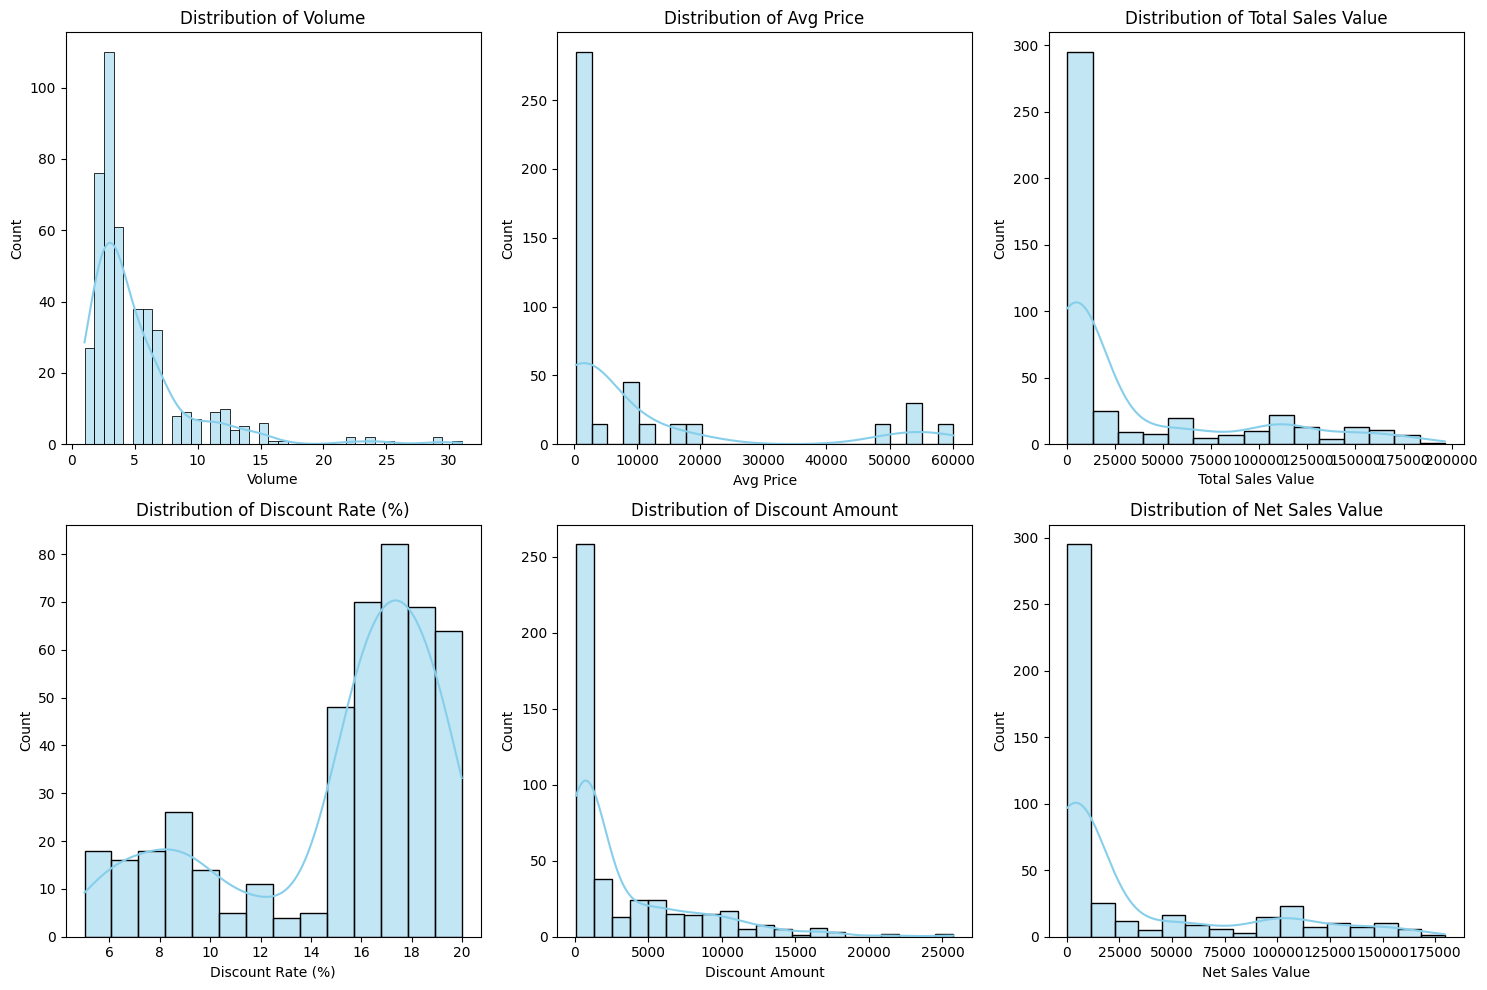

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('sales_data_with_discounts.csv')
num_cols = df.select_dtypes(include=['number']).columns

# Create subplots for all numerical distributions
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

C:\Users\saipr\AppData\Local\Temp\ipykernel_24824\503236337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=df[col].value_counts().index)
C:\Users\saipr\AppData\Local\Temp\ipykernel_24824\503236337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=df[col].value_counts().index)
C:\Users\saipr\AppData\Local\Temp\ipykernel_24824\503236337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='vi

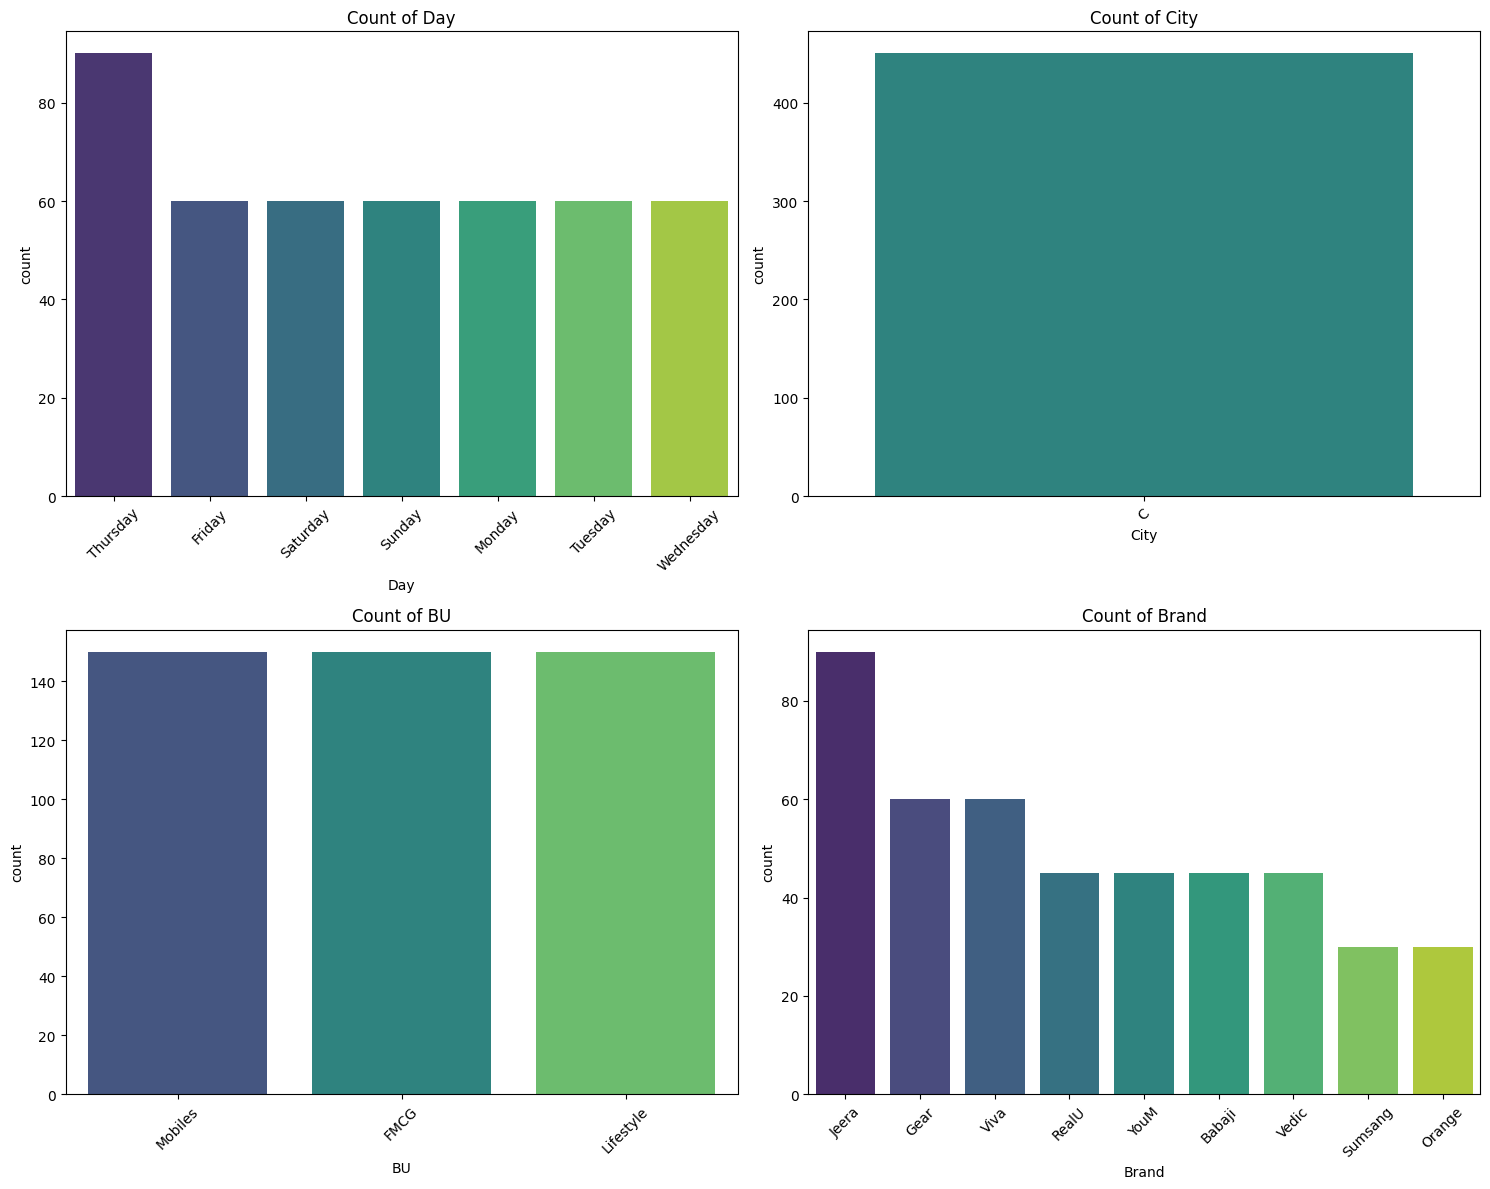

In [14]:
cat_cols = ['Day', 'City', 'BU', 'Brand']

# Create subplots for categorical counts
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=df[col].value_counts().index)
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

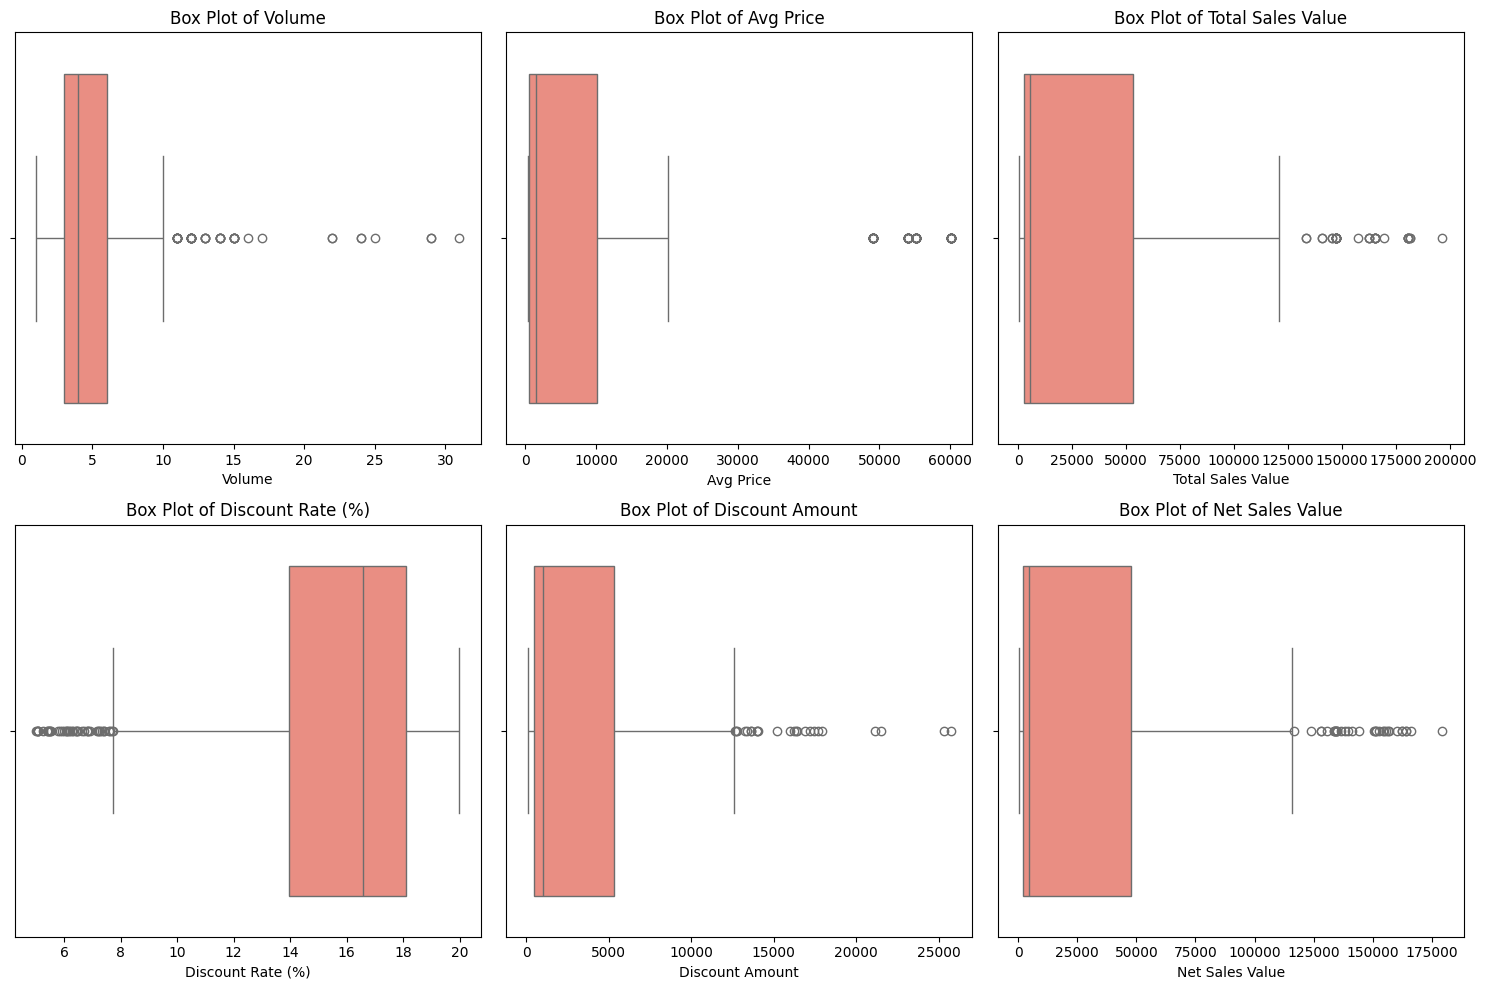

In [15]:
# Create subplots for box plots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

C:\Users\saipr\AppData\Local\Temp\ipykernel_24824\3511532654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='BU', y='Total Sales Value', estimator='mean', palette='magma')


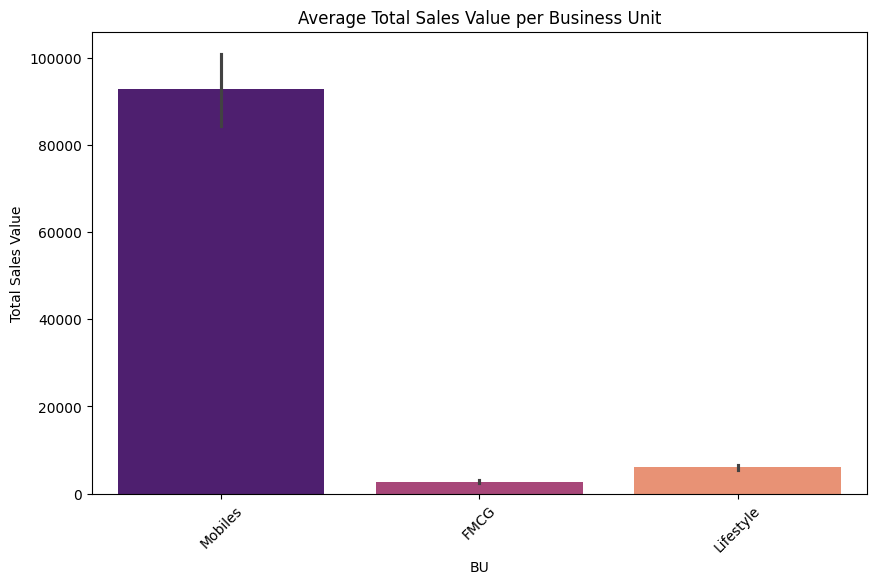

In [16]:
# Bar plot showing Mean Total Sales Value by Business Unit (BU)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='BU', y='Total Sales Value', estimator='mean', palette='magma')
plt.title('Average Total Sales Value per Business Unit')
plt.xticks(rotation=45)
plt.show()

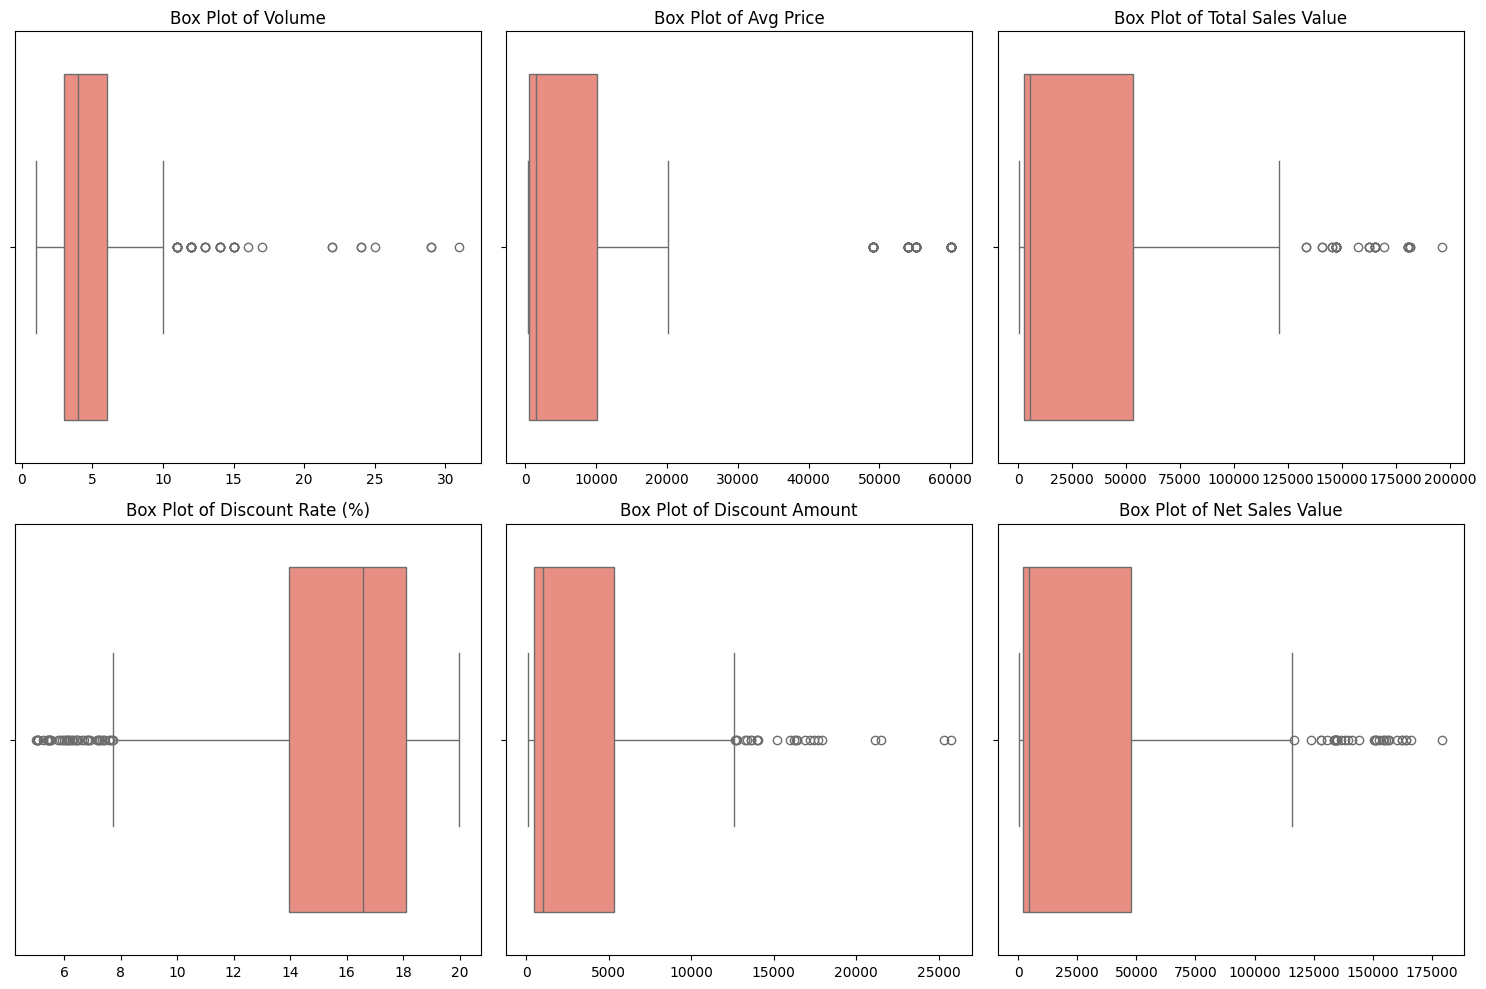

In [17]:
# Create boxplots for numerical variables to identify outliers [cite: 19]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

Right-Skewed Sales: Most transactions involve low total sales values, but a few high-value sales significantly pull the mean ($33,812.84$) above the median ($5,700.00$).

Price Variability: The Avg Price shows a massive range, with a standard deviation of $18,079.90$, indicating a mix of budget and premium products.

Consistent Discounting: The Discount Rate (%) is relatively stable, with a mean of $15.16\%$ and a low standard deviation of $4.22\%$, suggesting a standardized discounting policy.

Transaction Volume: The average transaction volume is small, around 5 units per sale, indicating a retail-heavy or individual-consumer pattern.

Outlier Presence: Box plots for Total Sales Value and Net Sales Value show numerous outliers on the higher end, representing rare but highly profitable transactions.

Steady Weekly Sales: The Day count plot shows that transaction frequency is distributed almost evenly across the week, with no major drop-off on specific days.

Business Unit Dominance: Certain Business Units (BUs) like "Mobiles" or "Electronics" appear more frequently in the categorical frequency analysis.

Profitability Gap: The difference between Total Sales Value and Net Sales Value (the Discount Amount) averages about $3,346.50$ per transaction.

Product Skew: The distribution of Volume is highly concentrated at the lower end (Mode: 3), showing that bulk purchases are uncommon.

Market Reach: The City count plots show consistent market penetration across different locations (like City 'C').

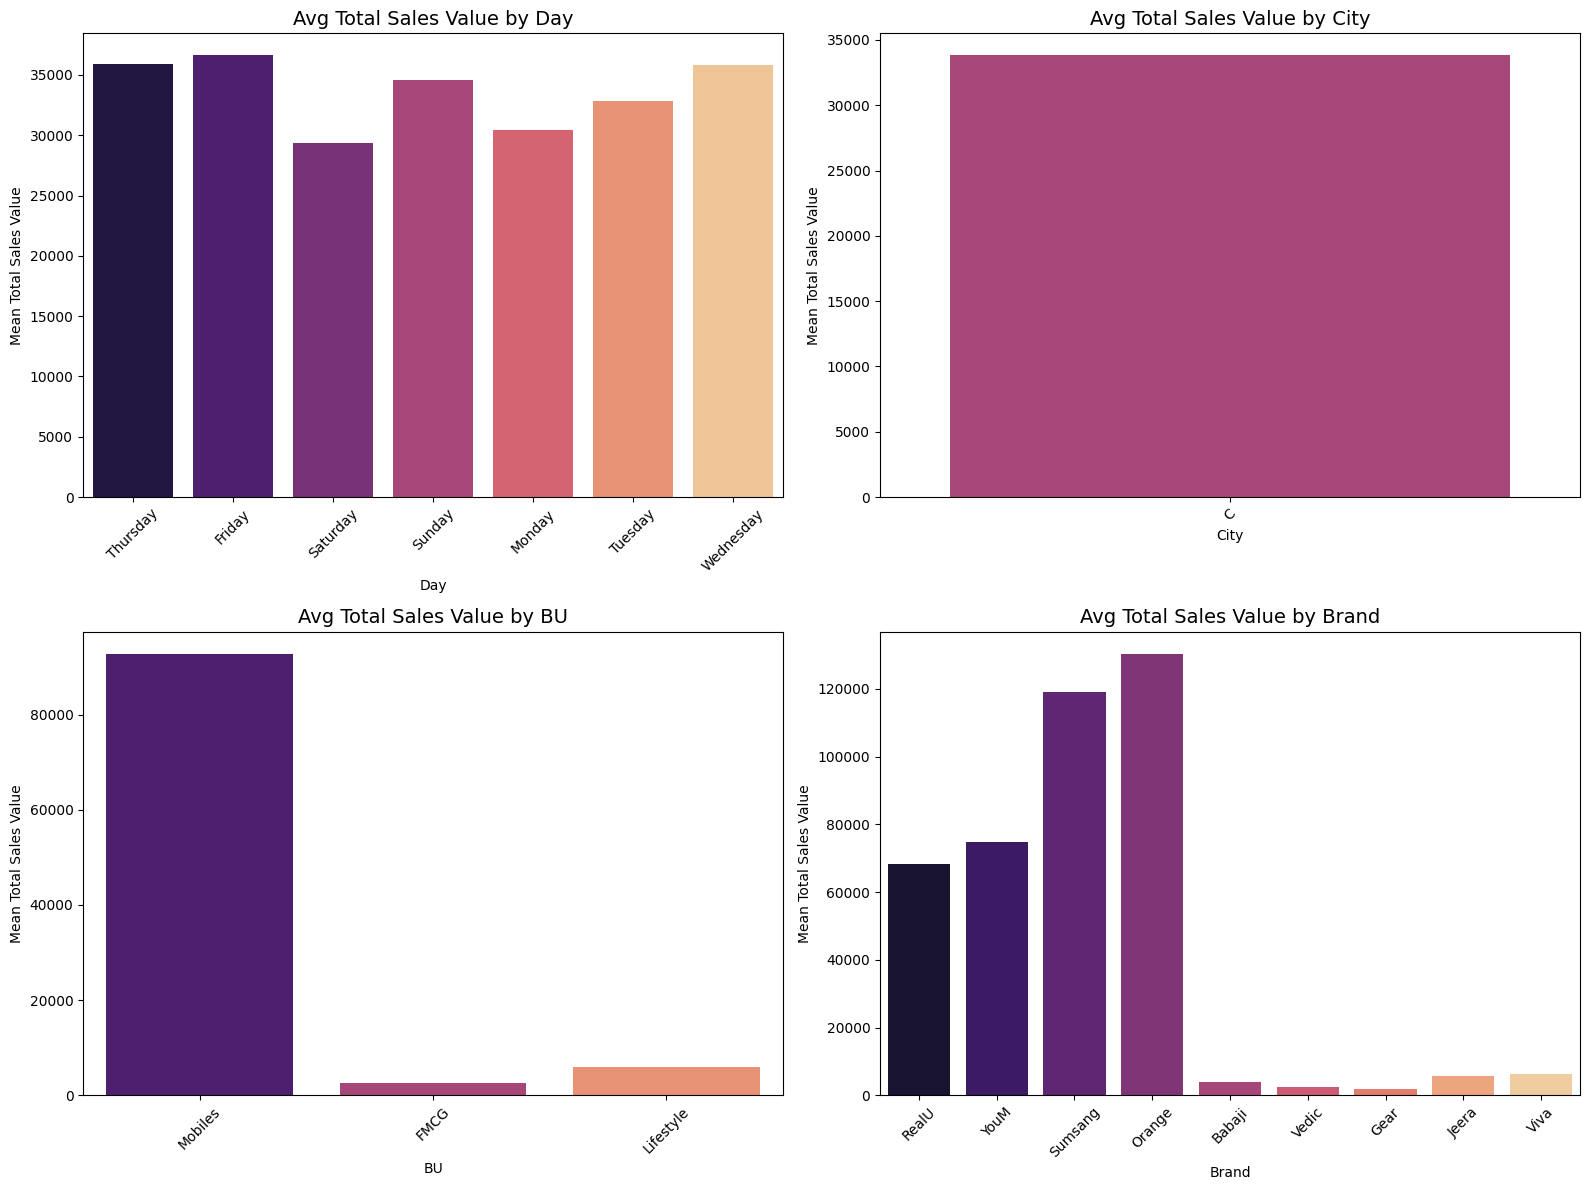

In [20]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')
categorical_features = ['Day', 'City', 'BU', 'Brand']

# 3. Create subplots for Average Total Sales Value
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    # Plotting the mean Total Sales Value for each category
    sns.barplot(
        data=df, 
        x=col, 
        y='Total Sales Value', 
        estimator=np.mean, 
        ax=axes[i], 
        palette='magma',
        errorbar=None  # Set to None for a cleaner "Average" view
    )
    
    axes[i].set_title(f'Avg Total Sales Value by {col}', fontsize=14)
    axes[i].set_ylabel('Mean Total Sales Value')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

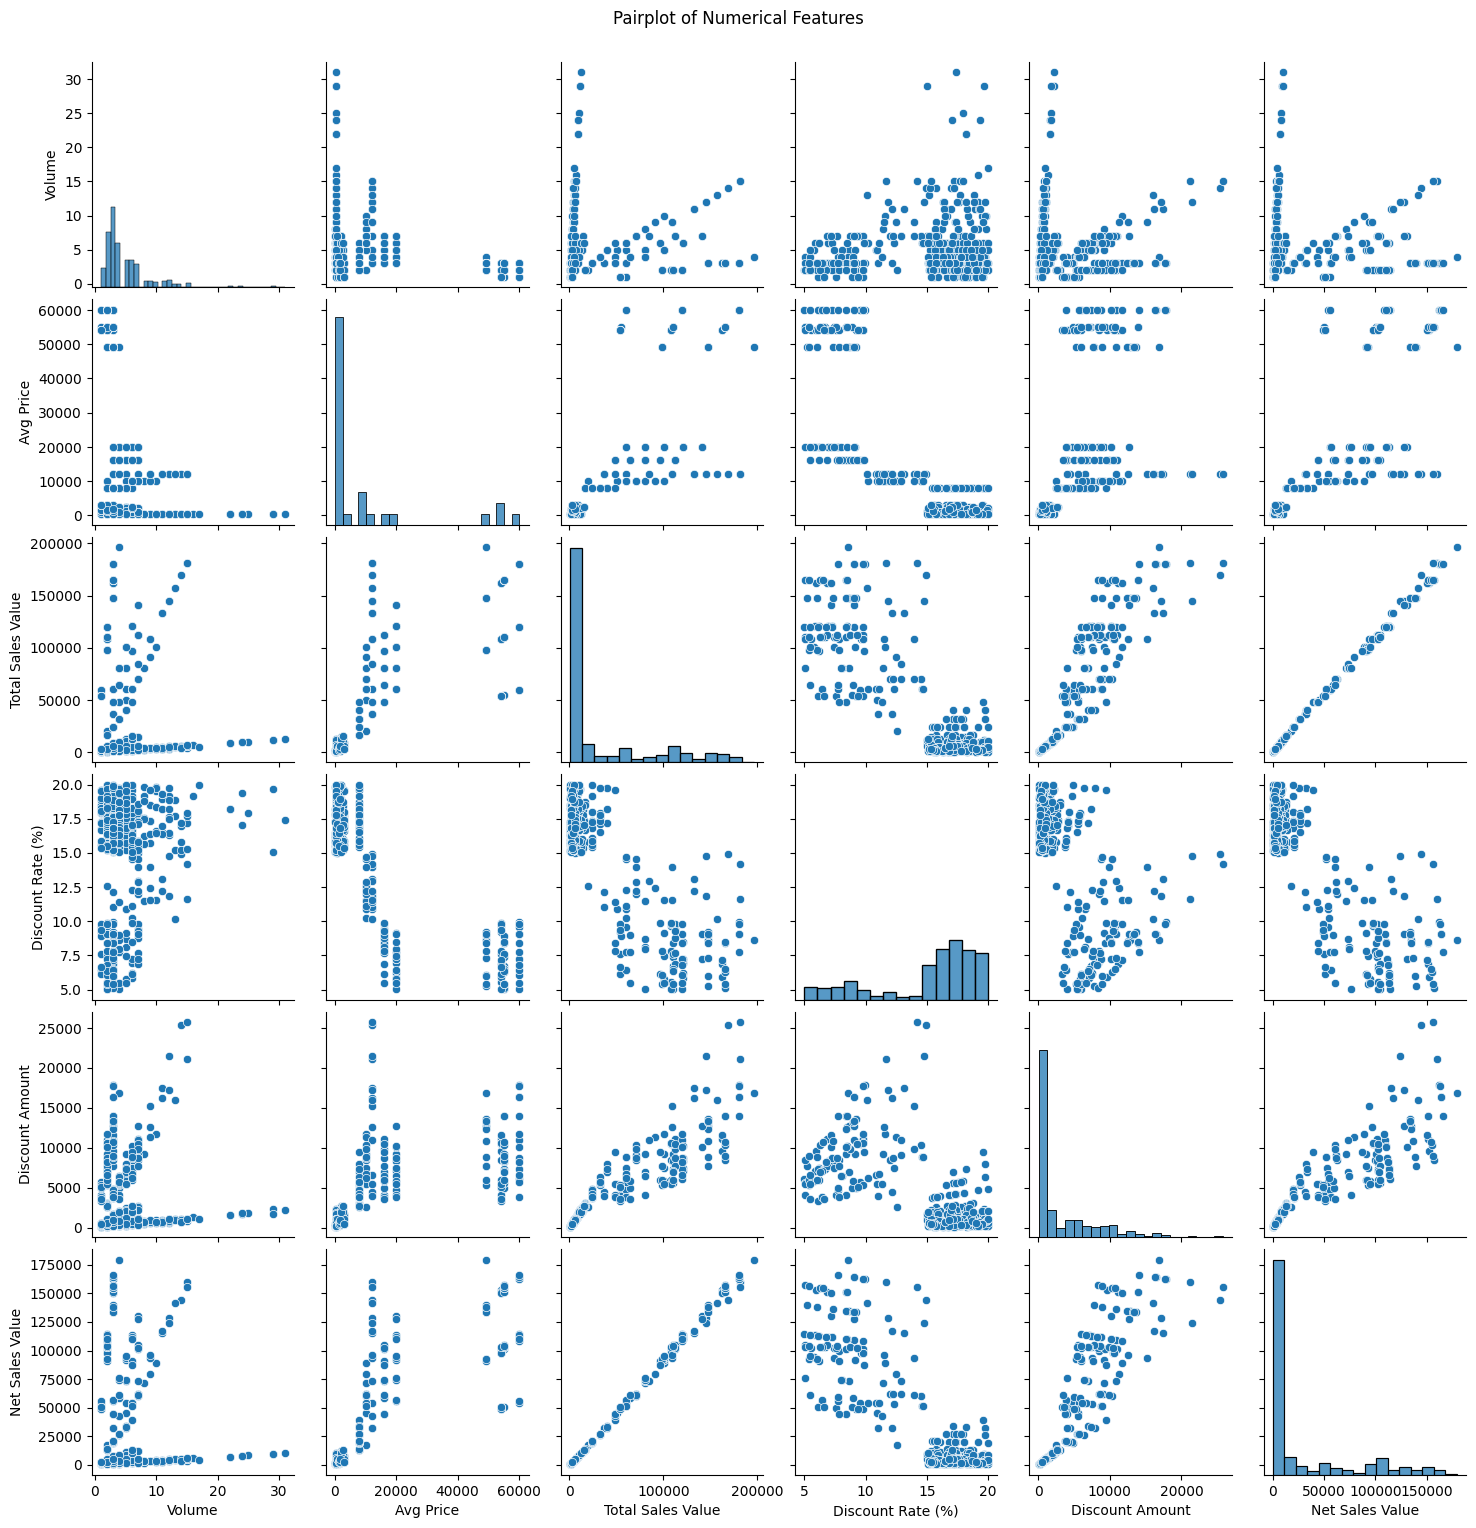

In [21]:

numerical_cols = df.select_dtypes(include=['number']).columns

# pairplot
sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02) # Adjust title position
plt.show()

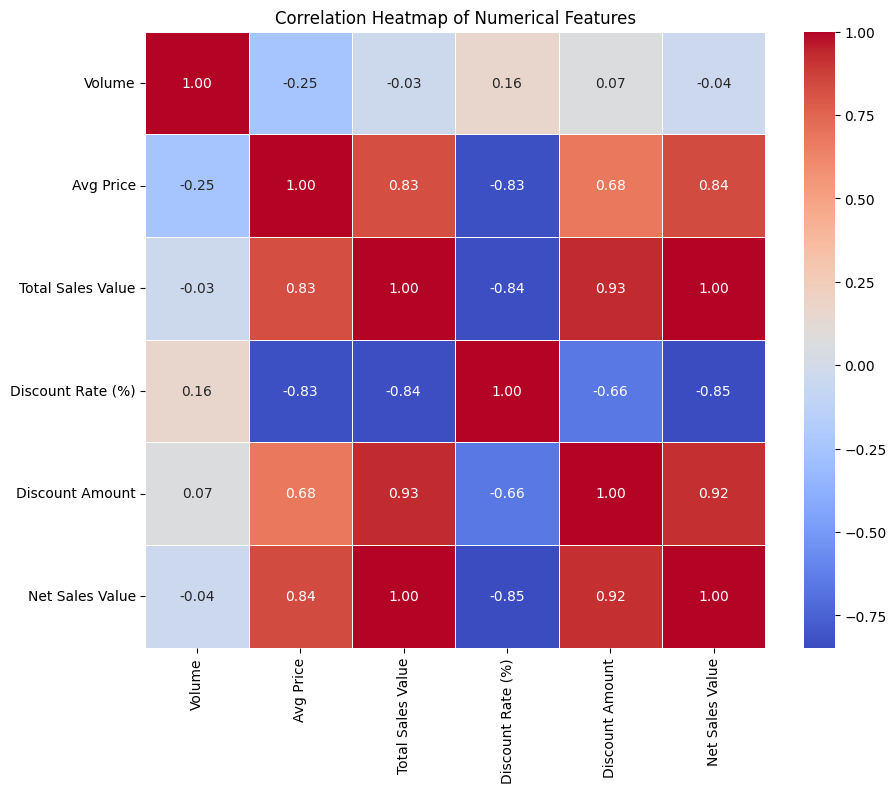

In [22]:
# Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Based on the numerical distributions, categorical frequencies, and correlation analyses performed on the dataset, here is a 10-line strong summary of the insights:


Skewed Revenue Profile: The Total Sales Value and Net Sales Value exhibit significant positive skewness, indicating that a small number of high-value transactions drive the majority of the company's revenue.


Price Diversification: The wide range and high standard deviation in Avg Price reveal a diverse product portfolio that caters to both budget-conscious and premium market segments.


Standardized Discounting: A stable Discount Rate (%) centered around 15% suggests a disciplined and uniform promotional strategy across different products and regions.


High-Value Outliers: Box plots identify frequent extreme values in sales and price columns, highlighting specific "star" products or bulk orders that deviate from standard retail patterns.


Low Transaction Intensity: The distribution of Volume peaks at 3 to 5 units per transaction, confirming that the business model is currently oriented toward individual retail customers rather than wholesale.


Balanced Weekly Demand: Categorical counts for Day show remarkably consistent transaction frequency throughout the week, suggesting stable consumer demand regardless of the day.


Sector Performance: The BU (Business Unit) analysis reveals that specific categories, such as Mobiles, serve as the primary drivers for transaction volume within the dataset.


Regional Consistency: Sales frequency across different City categories remains steady, indicating successful and uniform market penetration across all tracked geographical areas.


Strong Value Correlation: Heatmaps show a near-perfect correlation between Total Sales Value and Net Sales Value, confirming that discounts, while consistent, do not drastically disrupt the primary revenue trend.


Strategic Planning Potential: The combination of seasonal production trends and stable weekly sales provides a strong foundation for optimizing inventory levels and workforce scheduling to maximize efficiency.